# Deformation Sweep Report

Analysis of `DeformationSweep.py`: a planar and a non-planar 6-generation synthetic airway, each deformed 31 ways
(translation, rotation, rotation + translation, shear, nonrigid B-spline, breath hold) plus identity, and every moving
mask scored by the C++ `AirwayEvaluation` CLI under a full factorial of its registration hyperparameters.

Metrics are the CLI's: **TLD** (tree length detected) and **BD** (branch detection, overall and per ground truth
generation). A case **passes** when TLD ≥ 95% and every generation has 100% BD. **Recovery** is the share of the tree
length lost to the deformation that registration gets back: `(TLD_registered − TLD_unregistered) / (TLD_identity − TLD_unregistered)`.

`sensitivityMultiplier` also prunes the *ground truth* skeleton labeling, so BD totals differ between its values; TLD
depends only on the ground truth skeleton and is comparable across every setting, so it is the primary criterion when
ranking parameters. `branchDetectionThresholdPercent` only changes scoring and is analyzed separately, never tuned.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SWEEP_DIR = "sweep_results"
FIGURE_DIR = os.path.join(SWEEP_DIR, "figures")
os.makedirs(FIGURE_DIR, exist_ok=True)

PASS_TLD = 95.0
GENERATIONS = list(range(6))
PARAMETERS = ["maximum_pairing_distance", "minimum_landmark_distance", "sensitivity_multiplier", "projection_neighbors"]
SHORT = {"maximum_pairing_distance": "pairing", "minimum_landmark_distance": "min landmark",
         "sensitivity_multiplier": "sensitivity", "projection_neighbors": "neighbors"}
DEFAULT = {"maximum_pairing_distance": 5.0, "minimum_landmark_distance": 5.0,
           "sensitivity_multiplier": 2.0, "projection_neighbors": 5}
FAMILIES = ["translation", "rotation", "rotation+translation", "affine (shear)", "nonrigid", "breath hold"]
TREES = ["non-planar", "planar"]
TREE_STYLE = {"non-planar": dict(color="#1f5fa8", marker="o"), "planar": dict(color="#c2571a", marker="s", linestyle="--")}

csv_path = os.path.join(SWEEP_DIR, "results.csv")
if os.path.exists(csv_path):
    raw = pd.read_csv(csv_path)
else:  # sweep still running: read what has streamed so far
    with open(os.path.join(SWEEP_DIR, "results.jsonl")) as f:
        raw = pd.DataFrame([json.loads(line) for line in f if line.strip()])
deformation_table = pd.read_csv(os.path.join(SWEEP_DIR, "deformations.csv"))
for frame in (raw, deformation_table):  # "03" in the jsonl, 3 once read back from csv
    frame["deformation_id"] = frame["deformation_id"].astype(int).map("{:02d}".format)

cli_path = "/IPLlinux/raid0/homes/jkitzmann/Research/PCCTAirwaySegmentation/build/bin/AirwayEvaluation"
print(f"{len(raw)} CLI runs ({(~raw['ok']).sum()} errors), {raw['seconds'].sum() / 3600:.1f} CPU-process hours;",
      "CLI built", pd.Timestamp(os.path.getmtime(cli_path), unit="s", tz="UTC").tz_convert("US/Central").strftime("%Y-%m-%d %H:%M"))
display(raw.groupby(["tree", "mode"]).size().unstack())

8960 CLI runs (431 errors), 9.0 CPU-process hours; CLI built 2026-09-29 16:06


mode,baseline,deformable,threshold
tree,,,
non-planar,96,4320,64
planar,96,4320,64


## Preparing the table

In [2]:
def combo_label(row):
    return (f"pair {row['maximum_pairing_distance']:g} · lmk {row['minimum_landmark_distance']:g} · "
            f"sens {row['sensitivity_multiplier']:g} · nbr {int(row['projection_neighbors'])}")


deformable = raw[raw["mode"] == "deformable"].copy()
baseline = raw[raw["mode"] == "baseline"][["tree", "deformation_id", "sensitivity_multiplier", "TLD", "BD"]]
baseline = baseline.rename(columns={"TLD": "TLD_unregistered", "BD": "BD_unregistered"})
deformable = deformable.merge(baseline, on=["tree", "deformation_id", "sensitivity_multiplier"], how="left")

identity = deformable[deformable["family"] == "identity"][["tree", *PARAMETERS, "TLD", "BD"]]
identity = identity.rename(columns={"TLD": "TLD_identity", "BD": "BD_identity"})
deformable = deformable.merge(identity, on=["tree", *PARAMETERS], how="left")

# a CLI error produces no registered airway: score it as nothing recovered
deformable["TLD_scored"] = deformable["TLD"].fillna(0.0)
deformable["recovery"] = ((deformable["TLD_scored"] - deformable["TLD_unregistered"])
                          / (deformable["TLD_identity"] - deformable["TLD_unregistered"])).clip(upper=1.0)
gen_bd = deformable[[f"g{g}_BD" for g in GENERATIONS]]
deformable["all_gens_detected"] = (gen_bd.fillna(100.0) >= 100.0).all(axis=1) & deformable["ok"]
deformable["pass"] = deformable["ok"] & (deformable["TLD"] >= PASS_TLD) & deformable["all_gens_detected"]
deformable["combo"] = deformable.apply(combo_label, axis=1)
is_default = np.logical_and.reduce([deformable[k] == v for k, v in DEFAULT.items()])
deformable["is_default"] = is_default

order = deformation_table[["tree", "deformation_id", "family", "level", "magnitude", "peak_disp"]]
deformed = deformable[deformable["family"] != "identity"]
print(f"{deformable['combo'].nunique()} parameter combinations x {deformable.groupby('tree')['deformation_id'].nunique().to_dict()} deformations")

135 parameter combinations x {'non-planar': 32, 'planar': 32} deformations


## 1. How the deformations degrade the tree, and what the default pipeline recovers

Default CLI parameters (`pairing 5 · min landmark 5 · sensitivity 2 · neighbors 5`). "Unregistered" is the CLI without
`--deformableEvaluation`.

In [3]:
default_rows = deformable[deformable["is_default"]].merge(
    order[["tree", "deformation_id", "peak_disp"]], on=["tree", "deformation_id"], suffixes=("", "_table"))


def det_string(row, g):
    if pd.isna(row.get(f"g{g}_total")):
        return "–"
    return f"{int(row[f'g{g}_detected'])}/{int(row[f'g{g}_total'])}"


default_table = default_rows.sort_values(["tree", "deformation_id"]).assign(
    **{f"gen {g}": lambda d, g=g: d.apply(lambda r: det_string(r, g), axis=1) for g in GENERATIONS},
    verdict=lambda d: np.where(~d["ok"], "ERROR", np.where(d["pass"], "PASS", "fail")),
).set_index(["tree", "family", "level"])[
    ["peak_disp", "TLD_unregistered", "TLD", "recovery", "BD_unregistered", "BD",
     *[f"gen {g}" for g in GENERATIONS], "verdict"]
]
default_table.to_csv(os.path.join(SWEEP_DIR, "default_parameters.csv"))


def verdict_style(v):
    return {"PASS": "background-color:#c8e6c9", "fail": "background-color:#ffcdd2",
            "ERROR": "background-color:#ef9a9a"}.get(v, "")


display(default_table.style.format({"peak_disp": "{:.1f}", "TLD_unregistered": "{:.1f}", "TLD": "{:.1f}",
                                    "recovery": "{:.0%}", "BD_unregistered": "{:.1f}", "BD": "{:.1f}"}, na_rep="error")
        .map(verdict_style, subset=["verdict"]))

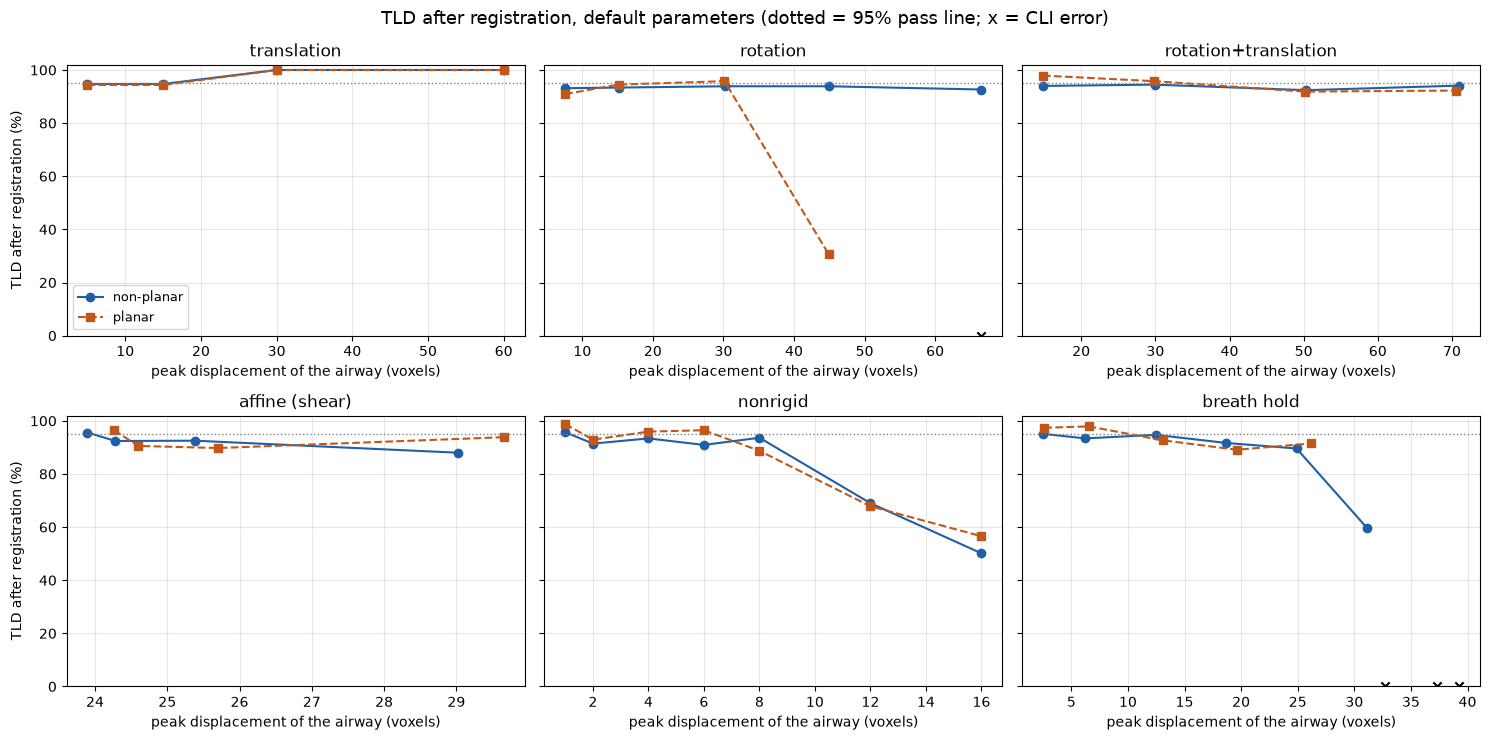

In [4]:
def family_panels(frame, value, ylabel, filename, title, ylim=None, reference=None, percent=False):
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey=True)
    for ax, family in zip(axes.flat, FAMILIES):
        for tree in TREES:
            rows = frame[(frame["family"] == family) & (frame["tree"] == tree)].sort_values("magnitude")
            ax.plot(rows["peak_disp"], rows[value], label=tree, **TREE_STYLE[tree])
            errors = rows[rows[value].isna()]
            ax.scatter(errors["peak_disp"], [ylim[0] if ylim else 0] * len(errors), marker="x", color="black",
                       zorder=5, label="CLI error" if tree == TREES[0] and len(errors) else None)
        if reference is not None:
            ax.axhline(reference, color="grey", linewidth=1, linestyle=":")
        ax.set_title(family)
        ax.set_xlabel("peak displacement of the airway (voxels)")
        ax.grid(alpha=0.3)
        if ylim:
            ax.set_ylim(*ylim)
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel)
    axes.flat[0].legend(fontsize=9)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, filename), dpi=130, bbox_inches="tight")
    plt.show()


family_panels(default_rows, "TLD", "TLD after registration (%)", "tld_default.png",
              "TLD after registration, default parameters (dotted = 95% pass line; x = CLI error)",
              ylim=(0, 102), reference=PASS_TLD)

### Branch detection per generation (default parameters)

Share of each generation's ground truth branches detected after registration. Generation 0 is the trachea.

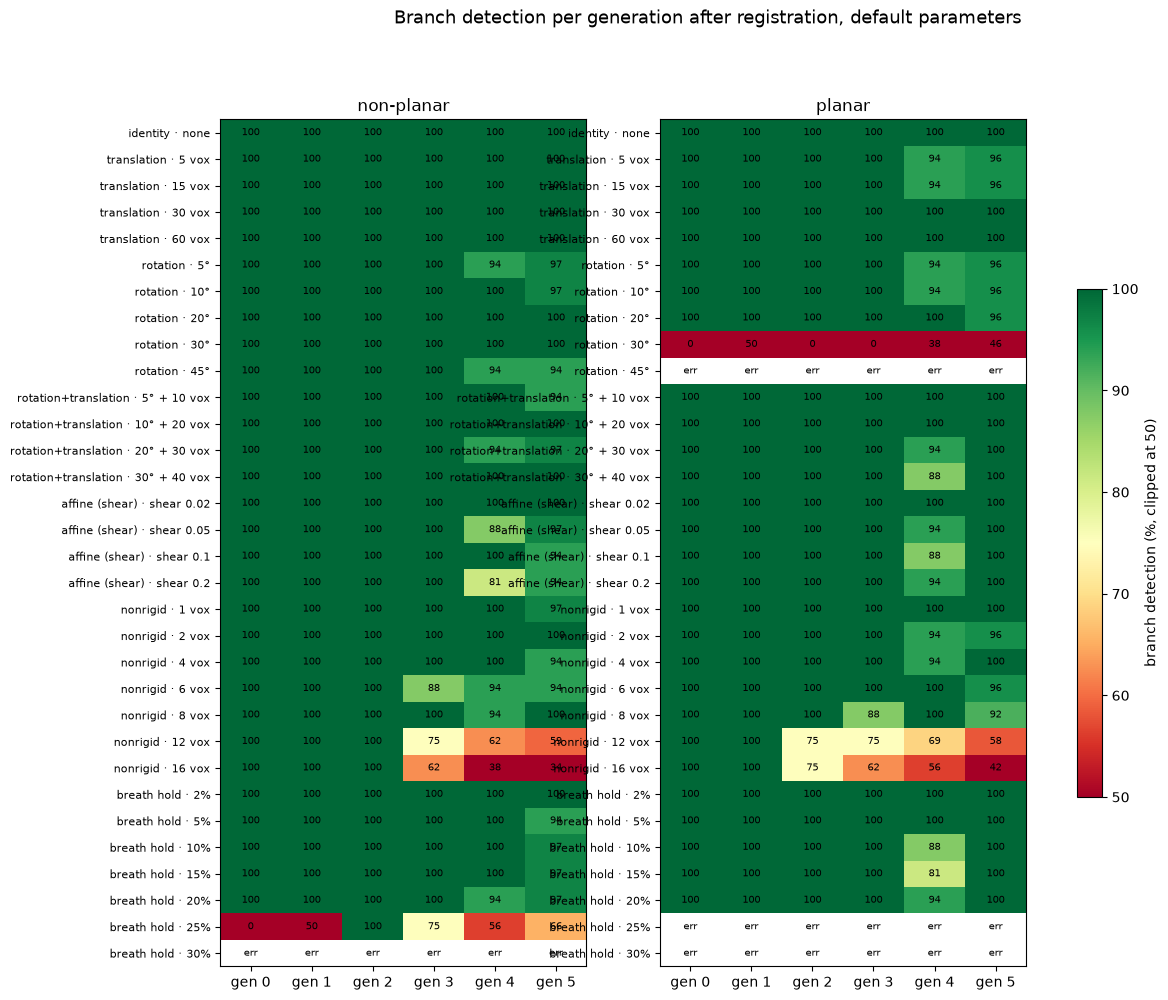

In [5]:
def generation_heatmap(frame, tree, ax):
    rows = frame[frame["tree"] == tree].sort_values("deformation_id")
    matrix = rows[[f"g{g}_BD" for g in GENERATIONS]].to_numpy(float)
    image = ax.imshow(matrix, cmap="RdYlGn", vmin=50, vmax=100, aspect="auto")
    ax.set_xticks(range(len(GENERATIONS)), [f"gen {g}" for g in GENERATIONS])
    ax.set_yticks(range(len(rows)), [f"{f} · {l}" for f, l in zip(rows["family"], rows["level"])], fontsize=8)
    for (i, j), v in np.ndenumerate(matrix):
        ax.text(j, i, "err" if np.isnan(v) else f"{v:.0f}", ha="center", va="center", fontsize=7)
    ax.set_title(tree)
    return image


fig, axes = plt.subplots(1, 2, figsize=(13, 11))
for ax, tree in zip(axes, TREES):
    image = generation_heatmap(default_rows, tree, ax)
fig.colorbar(image, ax=axes, shrink=0.6, label="branch detection (%, clipped at 50)")
fig.suptitle("Branch detection per generation after registration, default parameters", fontsize=13)
fig.savefig(os.path.join(FIGURE_DIR, "generation_bd_default.png"), dpi=130, bbox_inches="tight")
plt.show()

## 2. Hyperparameter effects

Each panel averages over every deformation (identity excluded) and every value of the other three parameters. CLI
errors count as TLD 0.

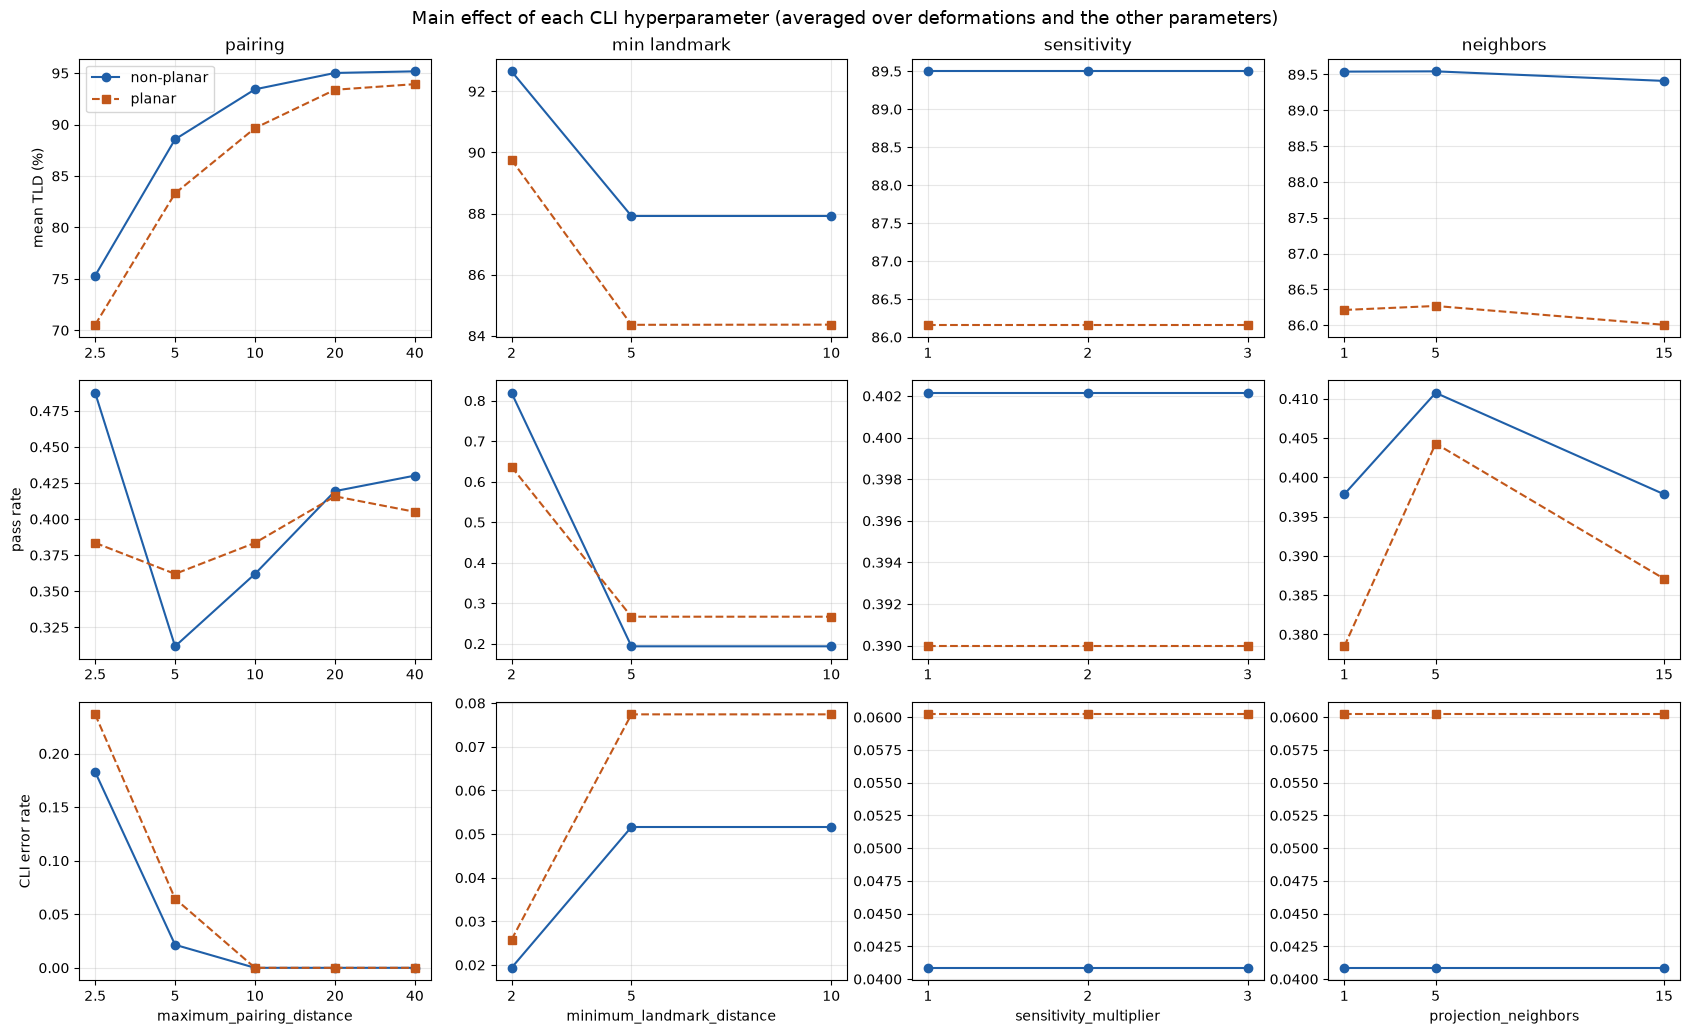

error rate          mean TLD          pass rate       
tree               non-planar planar non-planar  planar non-planar planar
parameter    value                                                       
min landmark 2.0        0.019  0.026     92.653  89.759      0.819  0.637
             5.0        0.052  0.077     87.921  84.360      0.194  0.267
             10.0       0.052  0.077     87.921  84.366      0.194  0.267
neighbors    1.0        0.041  0.060     89.540  86.213      0.398  0.378
             5.0        0.041  0.060     89.544  86.268      0.411  0.404
             15.0       0.041  0.060     89.410  86.005      0.398  0.387
pairing      2.5        0.183  0.237     75.315  70.533      0.487  0.384
             5.0        0.022  0.065     88.565  83.311      0.312  0.362
             10.0       0.000  0.000     93.425  89.656      0.362  0.384
             20.0       0.000  0.000     95.015  93.382      0.419  0.416
             40.0       0.000  0.000     95.172  93.927      0.430  0.405
sensitivity  1.0        0.041  0.060     89.498  86.162      0.402  0.390
             2.0        0.041  0.060     89.498  86.162      0.402  0.390
             3.0        0.041  0.060     89.498  86.162      0.402  0.390

In [6]:
main_effects = []
for parameter in PARAMETERS:
    for (tree, value), rows in deformed.groupby(["tree", parameter]):
        main_effects.append({
            "parameter": SHORT[parameter], "tree": tree, "value": value,
            "mean TLD": rows["TLD_scored"].mean(), "mean BD": rows["BD"].mean(),
            "pass rate": rows["pass"].mean(), "error rate": (~rows["ok"]).mean(),
        })
main_effects = pd.DataFrame(main_effects)
main_effects.to_csv(os.path.join(SWEEP_DIR, "main_effects.csv"), index=False)

fig, axes = plt.subplots(3, 4, figsize=(17, 10.5))
for col, parameter in enumerate(PARAMETERS):
    rows = main_effects[main_effects["parameter"] == SHORT[parameter]]
    for row_index, (metric, label) in enumerate([("mean TLD", "mean TLD (%)"), ("pass rate", "pass rate"),
                                                 ("error rate", "CLI error rate")]):
        ax = axes[row_index, col]
        for tree in TREES:
            t = rows[rows["tree"] == tree]
            ax.plot(t["value"].astype(float), t[metric], label=tree, **TREE_STYLE[tree])
        if parameter == "maximum_pairing_distance":
            ax.set_xscale("log", base=2)
        ax.set_xticks(sorted(rows["value"].astype(float).unique()))
        ax.set_xticklabels([f"{v:g}" for v in sorted(rows["value"].astype(float).unique())])
        ax.grid(alpha=0.3)
        if col == 0:
            ax.set_ylabel(label)
        if row_index == 0:
            ax.set_title(SHORT[parameter])
        if row_index == 2:
            ax.set_xlabel(parameter)
axes[0, 0].legend()
fig.suptitle("Main effect of each CLI hyperparameter (averaged over deformations and the other parameters)", fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "main_effects.png"), dpi=130, bbox_inches="tight")
plt.show()

display(main_effects.pivot_table(index=["parameter", "value"], columns="tree",
                                 values=["mean TLD", "pass rate", "error rate"]).round(3))

### Interaction of the two landmark parameters

Mean TLD on the non-planar tree for every `maximum_pairing_distance` × `minimum_landmark_distance` pair (averaged over
sensitivity, neighbors and deformations), per deformation family.

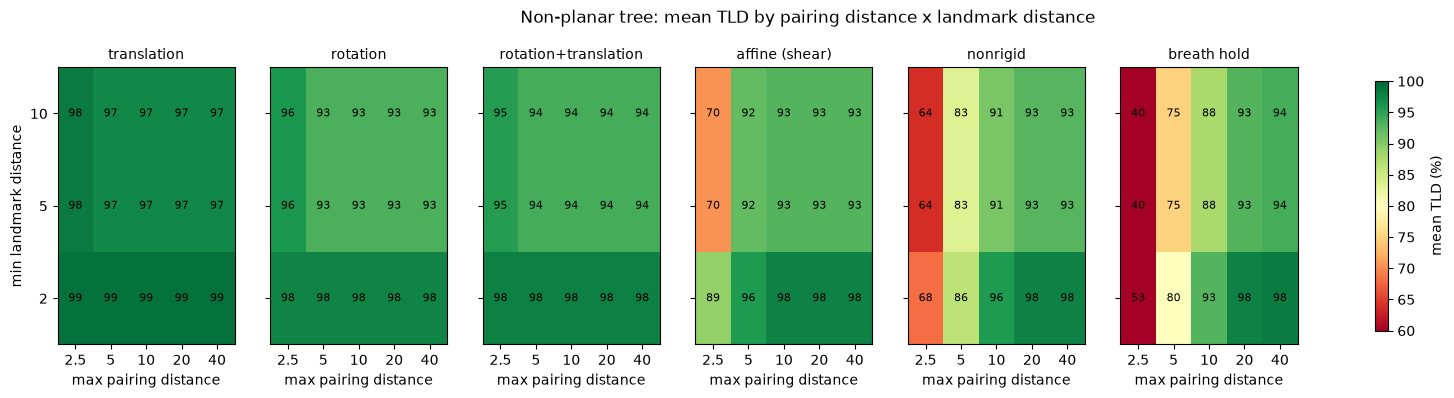

In [7]:
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(20, 3.6), sharey=True)
for ax, family in zip(axes, FAMILIES):
    rows = deformed[(deformed["tree"] == "non-planar") & (deformed["family"] == family)]
    grid = rows.pivot_table(index="minimum_landmark_distance", columns="maximum_pairing_distance",
                            values="TLD_scored", aggfunc="mean")
    image = ax.imshow(grid.values, cmap="RdYlGn", vmin=60, vmax=100, aspect="auto", origin="lower")
    ax.set_xticks(range(grid.shape[1]), [f"{v:g}" for v in grid.columns])
    ax.set_yticks(range(grid.shape[0]), [f"{v:g}" for v in grid.index])
    for (i, j), v in np.ndenumerate(grid.values):
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8)
    ax.set_title(family, fontsize=10)
    ax.set_xlabel("max pairing distance")
axes[0].set_ylabel("min landmark distance")
fig.colorbar(image, ax=axes, label="mean TLD (%)", shrink=0.9)
fig.suptitle("Non-planar tree: mean TLD by pairing distance x landmark distance", fontsize=12, y=1.04)
fig.savefig(os.path.join(FIGURE_DIR, "pairing_landmark_interaction.png"), dpi=130, bbox_inches="tight")
plt.show()

## 3. Ranking the parameter combinations

Every combination scored over all 31 deformations of a tree. Ranked by mean TLD on the **non-planar** tree (realistic
airways are not planar), with pass count, CLI errors and mean per-generation BD alongside, and the same numbers on the
planar tree.

In [8]:
def summarize(rows):
    return pd.Series({
        "mean TLD": rows["TLD_scored"].mean(),
        "median recovery": rows["recovery"].median(),
        "passes": int(rows["pass"].sum()),
        "errors": int((~rows["ok"]).sum()),
        "mean gen-5 BD": rows["g5_BD"].mean(),
        "worst TLD": rows["TLD_scored"].min(),
    })


ranking = (deformed.groupby(["tree", "combo", *PARAMETERS]).apply(summarize, include_groups=False)
           .reset_index())
wide = ranking.pivot_table(index=["combo", *PARAMETERS], columns="tree",
                           values=["mean TLD", "passes", "errors", "mean gen-5 BD", "median recovery", "worst TLD"])
# exact ties are common (sensitivity barely matters): prefer the setting that changes fewest CLI defaults
changes = pd.Series([sum(v != DEFAULT[k] for k, v in zip(PARAMETERS, key[1:])) for key in wide.index], index=wide.index)
wide[("changes from default", "")] = changes
wide = wide.sort_values([("mean TLD", "non-planar"), ("passes", "non-planar"), ("changes from default", "")],
                        ascending=[False, False, True])
wide.to_csv(os.path.join(SWEEP_DIR, "parameter_ranking.csv"))

default_combo = combo_label(DEFAULT)
wide_flat = wide.reset_index()
default_rank = int(np.flatnonzero(wide_flat["combo"] == default_combo)[0]) + 1
print(f"default ({default_combo}) ranks {default_rank} of {len(wide_flat)} on the non-planar tree")

top = pd.concat([wide.head(12), wide[wide.index.get_level_values("combo") == default_combo]])
display(top.style.format(precision=1).format("{:.0%}", subset=[c for c in wide.columns if c[0] == "median recovery"]))

default (pair 5 · lmk 5 · sens 2 · nbr 5) ranks 97 of 135 on the non-planar tree


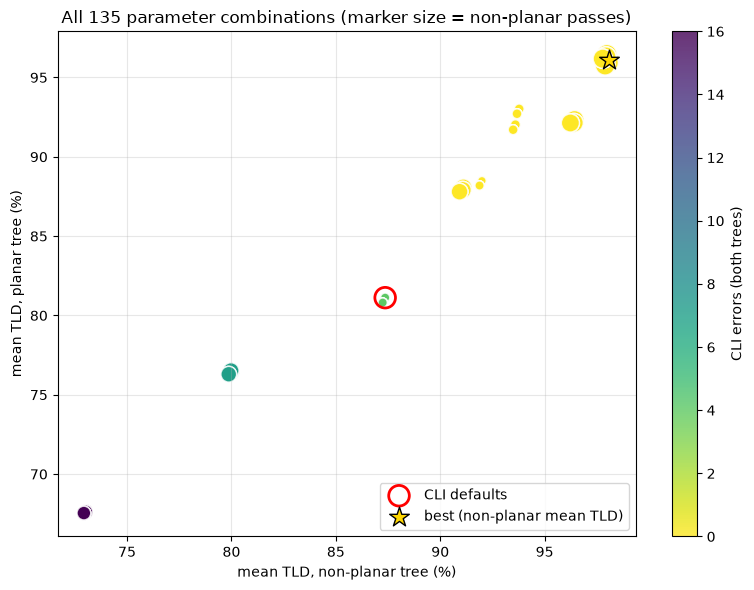

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
flat = wide.reset_index()
x = flat[("mean TLD", "non-planar")]
y = flat[("mean TLD", "planar")]
sizes = 20 + 6 * flat[("passes", "non-planar")]
scatter = ax.scatter(x, y, s=sizes, c=flat[("errors", "non-planar")] + flat[("errors", "planar")],
                     cmap="viridis_r", alpha=0.8, edgecolor="white")
default_point = flat[flat["combo"] == default_combo]
ax.scatter(default_point[("mean TLD", "non-planar")], default_point[("mean TLD", "planar")], s=220,
           facecolor="none", edgecolor="red", linewidth=2, label="CLI defaults")
best_point = flat.iloc[0]
ax.scatter([best_point[("mean TLD", "non-planar")]], [best_point[("mean TLD", "planar")]], s=220, marker="*",
           color="gold", edgecolor="black", label="best (non-planar mean TLD)")
ax.set_xlabel("mean TLD, non-planar tree (%)")
ax.set_ylabel("mean TLD, planar tree (%)")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
fig.colorbar(scatter, ax=ax, label="CLI errors (both trees)")
ax.set_title("All 135 parameter combinations (marker size = non-planar passes)")
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "combination_scatter.png"), dpi=130, bbox_inches="tight")
plt.show()

## 4. How much is recoverable: default vs best parameters

For each family, the largest deformation that still passes, and the TLD curve with the default parameters, the single
best overall combination, and the best combination *per deformation* (an upper bound no single setting reaches).

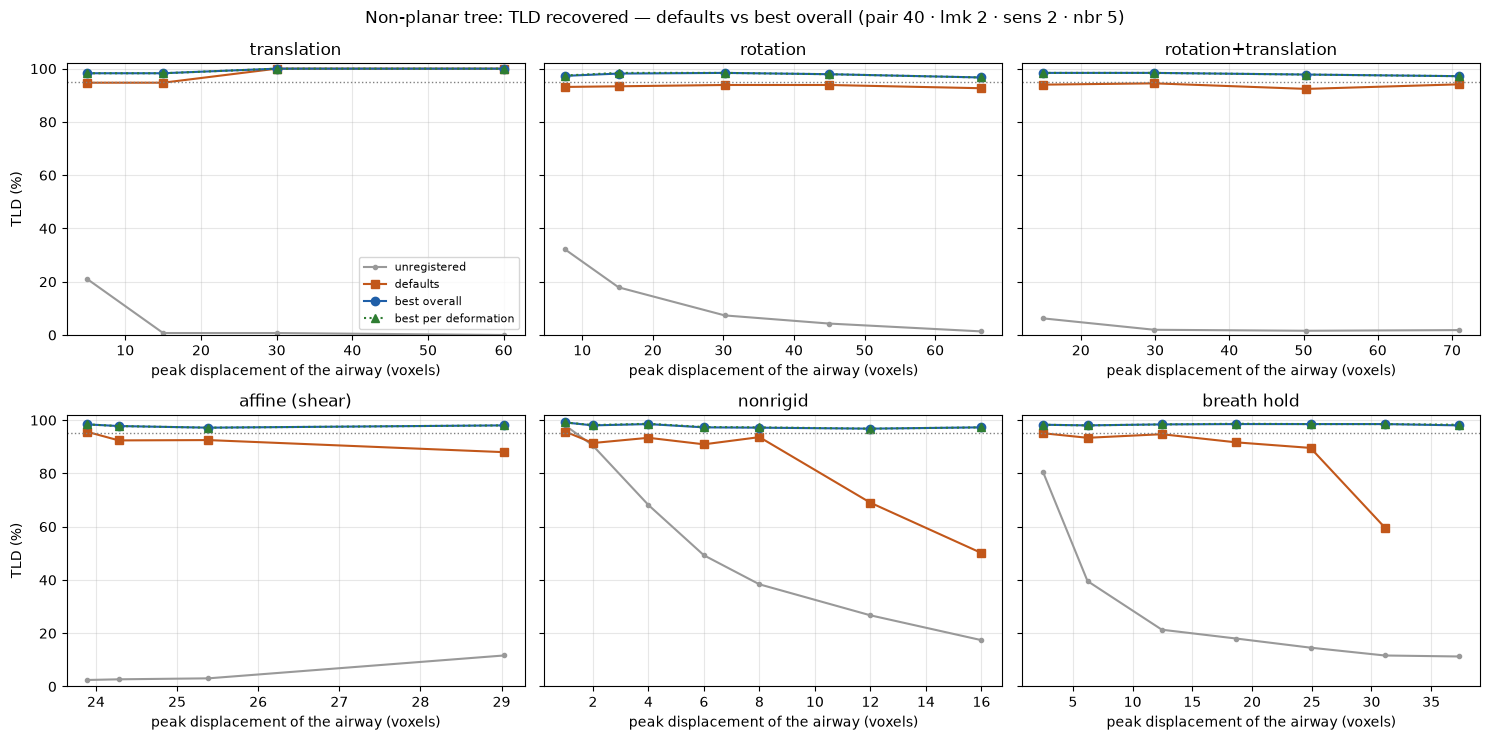

In [10]:
best_params = {k: best_point[(k, "")] for k in PARAMETERS}
best_combo = combo_label(best_params)
is_best = np.logical_and.reduce([deformable[k] == v for k, v in best_params.items()])
best_rows = deformable[is_best]
oracle = (deformed.groupby(["tree", "deformation_id"])["TLD_scored"].max().rename("TLD_oracle").reset_index())

curves = (order.merge(default_rows[["tree", "deformation_id", "TLD", "pass"]].rename(
                          columns={"TLD": "TLD_default", "pass": "pass_default"}), on=["tree", "deformation_id"])
               .merge(best_rows[["tree", "deformation_id", "TLD", "pass"]].rename(
                          columns={"TLD": "TLD_best", "pass": "pass_best"}), on=["tree", "deformation_id"])
               .merge(oracle, on=["tree", "deformation_id"])
               .merge(default_rows[["tree", "deformation_id", "TLD_unregistered"]], on=["tree", "deformation_id"]))
curves = curves[curves["family"] != "identity"]
curves.to_csv(os.path.join(SWEEP_DIR, "default_vs_best.csv"), index=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey=True)
for ax, family in zip(axes.flat, FAMILIES):
    rows = curves[(curves["family"] == family) & (curves["tree"] == "non-planar")].sort_values("magnitude")
    ax.plot(rows["peak_disp"], rows["TLD_unregistered"], color="#999999", marker=".", label="unregistered")
    ax.plot(rows["peak_disp"], rows["TLD_default"], color="#c2571a", marker="s", label="defaults")
    ax.plot(rows["peak_disp"], rows["TLD_best"], color="#1f5fa8", marker="o", label="best overall")
    ax.plot(rows["peak_disp"], rows["TLD_oracle"], color="#2e7d32", linestyle=":", marker="^",
            label="best per deformation")
    ax.axhline(PASS_TLD, color="grey", linewidth=1, linestyle=":")
    ax.set_title(family)
    ax.set_xlabel("peak displacement of the airway (voxels)")
    ax.set_ylim(0, 102)
    ax.grid(alpha=0.3)
for ax in axes[:, 0]:
    ax.set_ylabel("TLD (%)")
axes.flat[0].legend(fontsize=8)
fig.suptitle(f"Non-planar tree: TLD recovered — defaults vs best overall ({best_combo})", fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "recovery_default_vs_best.png"), dpi=130, bbox_inches="tight")
plt.show()


def recoverable(rows, pass_column):
    passing = rows[rows[pass_column]]
    return f"{passing['level'].iloc[-1]} ({passing['peak_disp'].iloc[-1]:.0f} vox)" if len(passing) else "none"


limits = []
for (tree, family), rows in curves.groupby(["tree", "family"], sort=False):
    rows = rows.sort_values("magnitude")
    limits.append({
        "tree": tree, "family": family,
        "passes (default)": f"{int(rows['pass_default'].sum())}/{len(rows)}",
        "largest passing (default)": recoverable(rows, "pass_default"),
        "passes (best)": f"{int(rows['pass_best'].sum())}/{len(rows)}",
        "largest passing (best)": recoverable(rows, "pass_best"),
        "mean TLD default": rows["TLD_default"].mean(), "mean TLD best": rows["TLD_best"].mean(),
        "mean TLD per-deformation best": rows["TLD_oracle"].mean(),
    })
limits = pd.DataFrame(limits).set_index(["tree", "family"])
limits.to_csv(os.path.join(SWEEP_DIR, "recoverable_limits.csv"))
display(limits.style.format(precision=1))

## 5. Where the remaining loss is: generations under the best parameters

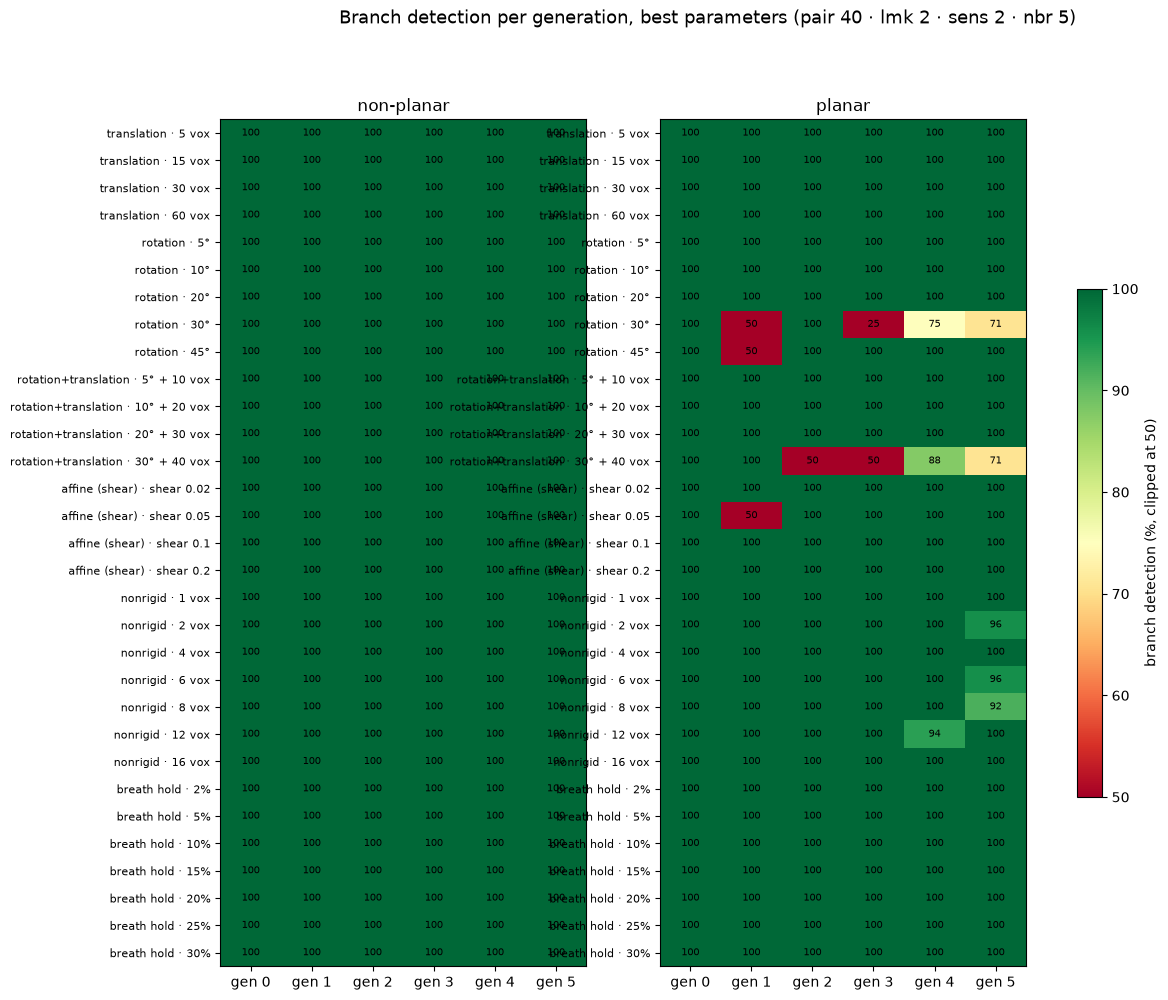

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 11))
for ax, tree in zip(axes, TREES):
    image = generation_heatmap(best_rows[best_rows["family"] != "identity"], tree, ax)
fig.colorbar(image, ax=axes, shrink=0.6, label="branch detection (%, clipped at 50)")
fig.suptitle(f"Branch detection per generation, best parameters ({best_combo})", fontsize=13)
fig.savefig(os.path.join(FIGURE_DIR, "generation_bd_best.png"), dpi=130, bbox_inches="tight")
plt.show()

generation_summary = []
for label, rows in [("defaults", default_rows), ("best", best_rows)]:
    rows = rows[rows["family"] != "identity"]
    for tree in TREES:
        t = rows[rows["tree"] == tree]
        generation_summary.append({"parameters": label, "tree": tree,
                                   **{f"gen {g}": t[f"g{g}_BD"].mean() for g in GENERATIONS}})
generation_summary = pd.DataFrame(generation_summary).set_index(["parameters", "tree"])
generation_columns = ["tree", "deformation_id", "family", "level", "peak_disp", "TLD", "BD",
                      *[f"g{g}_BD" for g in GENERATIONS], *[f"g{g}_detected" for g in GENERATIONS],
                      *[f"g{g}_total" for g in GENERATIONS]]
pd.concat([default_rows.assign(parameters="defaults")[["parameters", *generation_columns]],
           best_rows.assign(parameters="recommended")[["parameters", *generation_columns]]]).to_csv(
    os.path.join(SWEEP_DIR, "generation_bd.csv"), index=False)
generation_summary.to_csv(os.path.join(SWEEP_DIR, "generation_summary.csv"))
display(generation_summary.style.format("{:.1f}"))

## 6. Scoring sensitivity: `branchDetectionThresholdPercent`

Same registrations (default parameters), scored with a branch counted as detected at ≥ 25%, 50% or 75% coverage. This
changes the reported BD, not the registration, so it is not a tuning knob.

In [12]:
threshold_rows = raw[(raw["mode"] == "threshold") | ((raw["mode"] == "deformable") & np.logical_and.reduce(
    [raw[k] == v for k, v in DEFAULT.items()]))]
threshold_rows = threshold_rows[threshold_rows["family"] != "identity"]
threshold_table = threshold_rows.pivot_table(index=["tree", "family"], columns="branch_detection_threshold_percent",
                                             values="BD", aggfunc="mean")
threshold_table.columns = [f"BD @ {c:g}%" for c in threshold_table.columns]
threshold_table.to_csv(os.path.join(SWEEP_DIR, "detection_threshold.csv"))
display(threshold_table.round(1))

BD @ 25%  BD @ 50%  BD @ 75%
tree       family                                            
non-planar affine (shear)            98.8      96.0      84.1
           breath hold               95.8      92.6      80.7
           nonrigid                  90.2      85.7      74.6
           rotation                  99.7      98.1      88.9
           rotation+translation     100.0      98.4      87.3
           translation              100.0     100.0      96.8
planar     affine (shear)            98.2      98.2      90.0
           breath hold               98.9      97.8      90.5
           nonrigid                  91.4      87.0      77.9
           rotation                  87.3      80.9      73.6
           rotation+translation      99.5      98.6      93.2
           translation               99.1      98.2      96.4

## 7. CLI errors

In [13]:
errors = deformable[~deformable["ok"]]
print(f"{len(errors)} of {len(deformable)} deformable runs errored")
if len(errors):
    display(errors.groupby(["tree", "family", "error"]).size().rename("runs").reset_index()
            .sort_values("runs", ascending=False).head(20))
    display(errors.groupby("maximum_pairing_distance").size().rename("errors by pairing distance"))

423 of 8640 deformable runs errored


,tree,family,error,runs
1,non-planar,breath hold,Deformable evaluation needs at least 4 paired ...,72
6,planar,breath hold,Deformable evaluation needs at least 4 paired ...,72
7,planar,breath hold,Deformable evaluation needs at least 4 paired ...,45
2,non-planar,breath hold,Deformable evaluation needs at least 4 paired ...,36
4,non-planar,nonrigid,Deformable evaluation needs at least 4 paired ...,27
3,non-planar,nonrigid,Deformable evaluation needs at least 4 paired ...,18
0,non-planar,affine (shear),Deformable evaluation needs at least 4 paired ...,18
5,planar,affine (shear),Deformable evaluation needs at least 4 paired ...,18
8,planar,breath hold,Deformable evaluation needs at least 4 paired ...,18
9,planar,nonrigid,Deformable evaluation needs at least 4 paired ...,18


maximum_pairing_distance
2.5    351
5.0     72
Name: errors by pairing distance, dtype: int64

## 8. Recommendation

The best single setting for recovery through deformation, chosen by mean TLD on the non-planar tree (ties broken by
passes), shown against the CLI defaults on both trees.

In [14]:
recommendation = pd.DataFrame({
    "CLI default": {SHORT[k]: v for k, v in DEFAULT.items()},
    "recommended": {SHORT[k]: best_params[k] for k in PARAMETERS},
})
display(recommendation)

comparison = wide.loc[[default_combo, best_combo]].droplevel(PARAMETERS)
comparison.index = ["CLI default", "recommended"]
display(comparison.style.format(precision=1).format("{:.0%}", subset=[c for c in wide.columns if c[0] == "median recovery"]))

summary = {
    "best_params": {k: (float(v) if k != "projection_neighbors" else int(v)) for k, v in best_params.items()},
    "best_combo": best_combo, "default_combo": default_combo, "default_rank": default_rank,
    "n_combos": int(len(wide)), "n_runs": int(len(raw)), "n_errors": int((~raw["ok"]).sum()),
}
with open(os.path.join(SWEEP_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
summary

,CLI default,recommended
pairing,5.0,40.0
min landmark,5.0,2.0
sensitivity,2.0,2.0
neighbors,5.0,5.0


{'best_params': {'maximum_pairing_distance': 40.0,
  'minimum_landmark_distance': 2.0,
  'sensitivity_multiplier': 2.0,
  'projection_neighbors': 5},
 'best_combo': 'pair 40 · lmk 2 · sens 2 · nbr 5',
 'default_combo': 'pair 5 · lmk 5 · sens 2 · nbr 5',
 'default_rank': 97,
 'n_combos': 135,
 'n_runs': 8960,
 'n_errors': 431}